# 05 — Tool comparison: ViraLift (tblastn) vs Liftoff (minimap2)

On the *same* records, same truth and same coordinate metric, how accurately does Liftoff
recover the target-gene coordinates compared with ViraLift's protein-guided tblastn lifting?

Liftoff (Shumate & Salzberg, 2021) lifts with **minimap2** nucleotide alignment; ViraLift lifts
with **tblastn** (protein-guided).

### Metric — fair to both tools (read this)
- **Coordinate-only.** A gene is correct if its lifted coordinates match truth (IoU >= 0.90 or
  both boundaries within +-6 bp). The CDS codon check is **disabled for both tools**
  (`codon_required_names=set()`): Liftoff does not report start/stop/frame, so holding only
  ViraLift to it would be unfair — and PRRSV ORF1b (a -1 ribosomal frameshift with no ATG start)
  can never pass it even when coordinates are exact.
- **Truth-anchored, reference-restricted denominator.** The denominator is the set of
  *reference genes present in each record's truth* (R n truth). A gene a tool fails to lift counts
  as incorrect (so a tool is not rewarded for skipping hard genes). Truth names that are not
  reference genes (e.g. 'polyprotein', 'ORF1ab', 'hypothetical protein', 'HNZK1', a single '3B'
  vs split '3B1/3B2/3B3') are not liftable from the reference by ANY reference-based tool and are
  excluded -- this matches the paper's accuracy harness and makes the absolute numbers comparable
  to Section 3.1.

This coordinate-only, truth-anchored number is the head-to-head metric. It is *stricter and
different* from ViraLift's standalone headline accuracy (which uses the full `run_lifting_accuracy`
harness with per-gene codon exemptions); do not conflate the two.

### How to run
1. `pip install liftoff` in the venv; ensure `minimap2` is on PATH.
2. Run all cells. Outputs in `outputs/` (`liftoff_summary.tsv`, `liftoff_accuracy.png`, ...).


In [1]:
from pathlib import Path
import sys, subprocess, shutil, tempfile
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt, pandas as pd
from Bio import SeqIO
from app.validation._shared.validation_utils import *
from app.src.lifting.tblastn_lifter import lift_all_tblastn

OUTPUT_DIR = Path('outputs'); OUTPUT_DIR.mkdir(exist_ok=True)
TOOL_COLORS = {'ViraLift': '#2f7d4f', 'Liftoff': '#b5651d'}
LIFTOFF = shutil.which('liftoff'); MINIMAP2 = shutil.which('minimap2')
print('liftoff :', LIFTOFF or 'NOT FOUND -> pip install liftoff')
print('minimap2:', MINIMAP2 or 'NOT FOUND -> put minimap2 on PATH')
assert LIFTOFF and MINIMAP2, 'Install liftoff + minimap2 in the venv, then re-run.'


liftoff : /opt/homebrew/Caskroom/miniforge/base/envs/viralift-liftoff/bin/liftoff
minimap2: /opt/homebrew/Caskroom/miniforge/base/envs/viralift-liftoff/bin/minimap2


In [2]:
# --- helpers ---
def write_reference_gff(bundle, gff_path):
    ref_id = bundle['record'].id; lines = ['##gff-version 3']
    for f in bundle['features']:
        name, s, e, strand = f['name'], f['start'], f['end'], f['strand']
        g, t = f'gene-{name}', f'rna-{name}'
        lines += [
            f'{ref_id}\tviralift\tgene\t{s}\t{e}\t.\t{strand}\t.\tID={g};Name={name}',
            f'{ref_id}\tviralift\tmRNA\t{s}\t{e}\t.\t{strand}\t.\tID={t};Parent={g};Name={name}',
            f'{ref_id}\tviralift\texon\t{s}\t{e}\t.\t{strand}\t.\tID=exon-{name};Parent={t}',
            f'{ref_id}\tviralift\tCDS\t{s}\t{e}\t.\t{strand}\t0\tID=cds-{name};Parent={t};Name={name}',
        ]
    Path(gff_path).write_text('\n'.join(lines) + '\n')

def liftoff_gff_to_rows(record_id, out_gff):
    agg = {}; p = Path(out_gff)
    if not p.exists(): return []
    for line in p.read_text().splitlines():
        if line.startswith('#') or not line.strip(): continue
        c = line.split('\t')
        if len(c) < 9 or c[2] != 'CDS': continue
        attrs = dict(kv.split('=', 1) for kv in c[8].split(';') if '=' in kv)
        name = attrs.get('Name') or attrs.get('Parent', '').replace('rna-', '')
        s, e, strand = int(c[3]), int(c[4]), c[6]
        if name not in agg: agg[name] = [s, e, strand]
        else: agg[name][0] = min(agg[name][0], s); agg[name][1] = max(agg[name][1], e)
    return [{'record_id': record_id, 'method': 'liftoff', 'pred_name': n,
             'pred_start': v[0], 'pred_end': v[1], 'strand': v[2],
             'has_start_codon': None, 'has_stop_codon': None, 'in_frame': None}
            for n, v in agg.items()]

def run_liftoff(ref_record, ref_gff, target_record):
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        ref_fa, tgt_fa, out_gff = tmp/'ref.fa', tmp/'target.fa', tmp/'out.gff'
        SeqIO.write(ref_record, str(ref_fa), 'fasta')
        SeqIO.write(target_record, str(tgt_fa), 'fasta')
        cmd = [LIFTOFF, str(tgt_fa), str(ref_fa), '-g', str(ref_gff),
               '-o', str(out_gff), '-u', str(tmp/'unmapped.txt'), '-dir', str(tmp/'intermediate')]
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)
        return liftoff_gff_to_rows(target_record.id, out_gff)

def coverage_rows(virus, tool, acc, truth, preds):
    """Truth-anchored, coordinate-only (codon check OFF for both tools).
    One row per TRUTH gene: found = a same-name prediction is coordinate-correct."""
    if preds:
        cmp = compare_predictions_to_truth(preds, truth, codon_required_names=set())
        correct = set(cmp.loc[cmp['coord_correct'], 'pred_name']) if 'coord_correct' in cmp.columns else set()
    else:
        correct = set()  # tool produced no prediction for this record -> every truth gene is a miss
    return [{'virus': virus, 'tool': tool, 'accession': acc, 'gene': t['name'],
             'found': t['name'] in correct} for t in truth]


In [3]:
DATASETS = [
    ('PRRS', DATA / 'PRRS' / 'PRRS_ref_test.gb', DATA / 'PRRS' / 'PRRS_100seq_anno.gb'),
    ('FMD',  DATA / 'FMD'  / 'FMD_ref_test.gb',  DATA / 'FMD'  / 'FMD_100seq_anno.gb'),
    ('PED',  DATA / 'PED'  / 'PED_ref_1.gb',     DATA / 'PED'  / 'PED_100seqs.gb'),
]

cov, run_rows = [], []
for virus, ref_path, query_path in DATASETS:
    bundle = load_reference_bundle(ref_path)
    validate_codons = bundle['feature_type'] == 'CDS'
    ref_names = sorted({f['name'] for f in bundle['features']})  # evaluable set R
    records = load_genbank_records(query_path)
    n_liftoff_ok = 0
    with tempfile.TemporaryDirectory() as gdir:
        ref_gff = Path(gdir) / 'ref.gff3'; write_reference_gff(bundle, ref_gff)
        for k, record in enumerate(records, 1):
            # Denominator = reference genes present in this record's truth (R n truth).
            # Truth names outside R (e.g. 'polyprotein', 'ORF1ab', 'HNZK1', '3B1/2/3')
            # are not liftable from the reference by ANY reference-based tool, so they
            # are excluded here -- matching the accuracy harness (parse_validation_truth_features).
            truth, _ = parse_truth_features(record, bundle['alias_lookup'], bundle['feature_type'],
                                            filter_nested=False, target_names=ref_names, keep_extra_names=[])
            if not truth: continue
            v_lift = lift_all_tblastn(bundle['features'], bundle['record'], record, validate_codons=validate_codons)
            v_preds = lifted_to_rows(record.id, v_lift, 'viralift')
            l_preds = run_liftoff(bundle['record'], ref_gff, record)
            if l_preds: n_liftoff_ok += 1
            cov += coverage_rows(virus, 'ViraLift', record.id, truth, v_preds)
            cov += coverage_rows(virus, 'Liftoff',  record.id, truth, l_preds)
            if k % 20 == 0: print(f'{virus}: {k}/{len(records)}')
    run_rows.append({'virus': virus, 'query_records': len(records),
                     'ref_feature_type': bundle['feature_type'],
                     'records_liftoff_produced_output': n_liftoff_ok})

cov_df = pd.DataFrame(cov)
cov_df.to_csv(OUTPUT_DIR / 'liftoff_coverage_per_gene.tsv', sep='\t', index=False)
pd.DataFrame(run_rows)


PRRS: 20/100
PRRS: 40/100
PRRS: 60/100
PRRS: 80/100
PRRS: 100/100
FMD: 20/100
FMD: 40/100
FMD: 60/100
FMD: 80/100
FMD: 100/100
PED: 20/100
PED: 40/100
PED: 60/100
PED: 80/100
PED: 100/100


,virus,query_records,ref_feature_type,records_liftoff_produced_output
0,PRRS,100,CDS,96
1,FMD,100,mat_peptide,98
2,PED,100,CDS,98


In [4]:
# Truth-anchored summary: correct / truth genes present
summary = (cov_df.groupby(['virus','tool'])
           .agg(truth_genes=('found','size'), correct=('found','sum'))
           .reset_index())
summary['coord_pct'] = (summary['correct'] / summary['truth_genes'] * 100).round(2)
summary = summary.sort_values(['virus','tool'])
summary.to_csv(OUTPUT_DIR / 'liftoff_summary.tsv', sep='\t', index=False)

wide = summary.pivot(index='virus', columns='tool', values='coord_pct')
wide['ViraLift_minus_Liftoff'] = (wide['ViraLift'] - wide['Liftoff']).round(2)
wide.to_csv(OUTPUT_DIR / 'liftoff_summary_wide.tsv', sep='\t')
print(summary.to_string(index=False)); print(); print(wide)


virus     tool  truth_genes  correct  coord_pct
  FMD  Liftoff         1172      900      76.79
  FMD ViraLift         1172     1170      99.83
  PED  Liftoff          505      501      99.21
  PED ViraLift          505      504      99.80
 PRRS  Liftoff          797      759      95.23
 PRRS ViraLift          797      794      99.62

tool   Liftoff  ViraLift  ViraLift_minus_Liftoff
virus                                           
FMD      76.79     99.83                   23.04
PED      99.21     99.80                    0.59
PRRS     95.23     99.62                    4.39


tool,Liftoff,ViraLift,ViraLift_minus_Liftoff
virus,,,
FMD,76.79,99.83,23.04
PED,99.21,99.80,0.59
PRRS,95.23,99.62,4.39


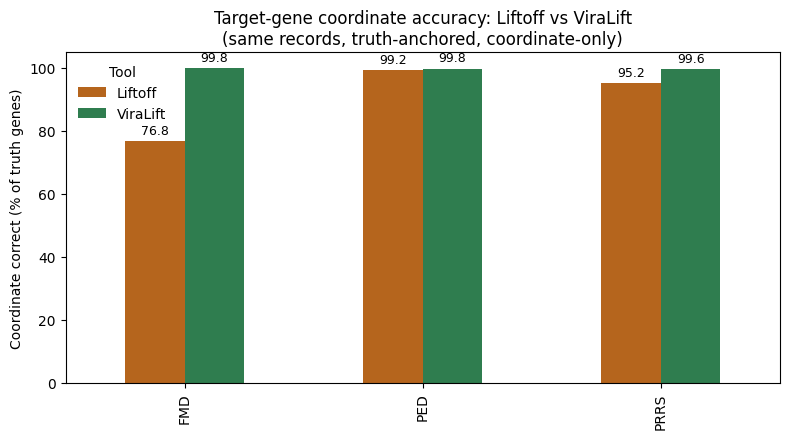

In [5]:
plot_df = summary.pivot(index='virus', columns='tool', values='coord_pct')[['Liftoff','ViraLift']]
ax = plot_df.plot(kind='bar', figsize=(8,4.5), color=[TOOL_COLORS['Liftoff'], TOOL_COLORS['ViraLift']])
ax.set_ylim(0,105); ax.set_ylabel('Coordinate correct (% of truth genes)'); ax.set_xlabel('')
ax.set_title('Target-gene coordinate accuracy: Liftoff vs ViraLift\n(same records, truth-anchored, coordinate-only)')
ax.legend(title='Tool', frameon=False)
for c in ax.containers: ax.bar_label(c, fmt='%.1f', padding=3, fontsize=9)
ax.figure.tight_layout(); ax.figure.savefig(OUTPUT_DIR / 'liftoff_accuracy.png', dpi=180, bbox_inches='tight')
wide


In [6]:
# Per-gene breakdown (where does each tool win/lose?)
per_gene = (cov_df.groupby(['virus','gene','tool'])
            .agg(n=('found','size'), correct=('found','sum')).reset_index())
per_gene['pct'] = (per_gene['correct']/per_gene['n']*100).round(1)
per_gene = per_gene.pivot_table(index=['virus','gene'], columns='tool', values='pct', fill_value=0)
per_gene.to_csv(OUTPUT_DIR / 'liftoff_per_gene.tsv', sep='\t')
per_gene


tool         Liftoff  ViraLift
virus gene                    
FMD   2A         3.1     100.0
      2B       100.0     100.0
      2C       100.0     100.0
      3A        91.8      99.0
      3B        93.8     100.0
      3Cpro    100.0     100.0
      3Dpol    100.0     100.0
      Lpro      87.8     100.0
      VP1       52.6     100.0
      VP2       55.1      99.0
      VP3       52.6     100.0
      VP4       84.7     100.0
PED   E        100.0     100.0
      M        100.0     100.0
      N        100.0     100.0
      ORF1a    100.0     100.0
      ORF1b     87.5      87.5
      ORF3      97.8     100.0
      S         99.0     100.0
PRRS  ORF1a     93.5     100.0
      ORF1b     93.3      97.8
      ORF2a     96.0     100.0
      ORF2b     91.8      98.0
      ORF3      96.0     100.0
      ORF4      96.0     100.0
      ORF5      96.0     100.0
      ORF6      96.0     100.0
      ORF7      96.0     100.0